In [38]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_regression

In [39]:
X,y = make_regression(n_samples=100,n_features=1,n_informative=1,n_targets=1,noise=20,random_state=13)

In [40]:
print(X.shape)
print(y.shape)

(100, 1)
(100,)


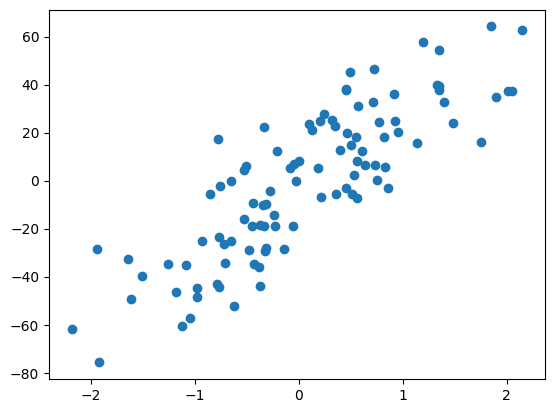

In [41]:
plt.scatter(X,y)

### at first applying linear regression

In [42]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(X,y)

print("Coeff is : ",lr.coef_)
print("Intercept is : ",lr.intercept_)

Coeff is :  [27.82809103]
Intercept is :  -2.29474455867698


## Now using Ridge Regression with alpha = 10 

In [43]:
from sklearn.linear_model import Ridge

rdgr = Ridge(alpha=10)

rdgr.fit(X,y)
print("Coeff : ",rdgr.coef_)
print("Intercept : ",rdgr.intercept_)

Coeff :  [24.9546267]
Intercept :  -2.1269130035235735


## Ridge Regression with alpha = 100

In [44]:
from sklearn.linear_model import Ridge

rdgr1 = Ridge(alpha=100)

rdgr1.fit(X,y)

print("Coeff : ",rdgr1.coef_)
print("Intercept : ",rdgr1.intercept_)

Coeff :  [12.93442104]
Intercept :  -1.4248441496033308


## Visualizing with graph

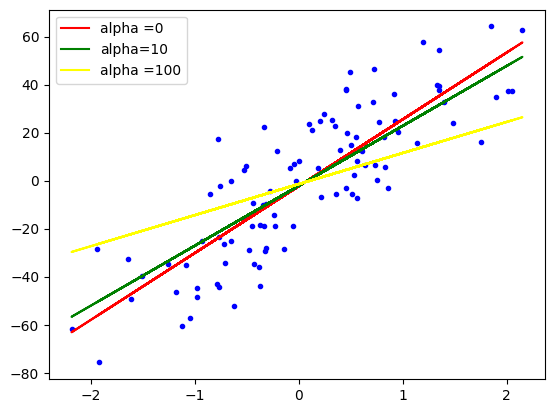

In [45]:
plt.plot(X,y,"b.")  # for data points which are in blue dotted color
plt.plot(X,lr.predict(X),color='red',label='alpha =0') # for linear regression
plt.plot(X,rdgr.predict(X),color="green",label='alpha=10')  # for ridge regression with alpha = 10
plt.plot(X,rdgr1.predict(X),color='yellow',label='alpha =100') # for ridge regression with alpha = 100
plt.legend()
plt.show()

## creating own Ridge Regression Class

In [46]:
class Ridge:
    
    def __init__(self,alpha=0.1):
        self.alpha =alpha
        self.m=None
        self.b=None

    def fit(self,X_train,y_train):

        num = 0
        den = 0

        for i in range(X_train.shape[0]):

            num = num + (y_train[i] - y_train.mean()) * (X_train[i] - X_train.mean())
            den = den + (X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean())

        self.m = num / (den +self.alpha)  # alpha means labmda
        self.b = y_train.mean() - self.m * X_train.mean()

        print(self.m,self.b)

In [49]:
rdg = Ridge(alpha=10)

rdg.fit(X,y)

[24.9546267] [-2.126913]


In [50]:
rdg1 =Ridge(alpha = 100)
rdg1.fit(X,y)


[12.93442104] [-1.42484415]
